## Equilibrium composition for solar thermolysis
This Jupyter notebook walks through the calculation of the equilibrium
composition of the gas-phase mixture in solar thermolysis as a function of
temperature and pressure using the Gibbs-free-energy-minimization method.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sklearn.preprocessing import normalize

#### Step 1: Read thermodynamic data

In [2]:
def factsage(p):
    """ Read thermodynamic data downloaded from FactSage """
    data = []
    with open(p, encoding="iso-8859-1") as f:
        for line in f:
            if "------" in line:
                break
        condition = ""
        while condition == "":
            for line in f:
                if "------" in line:
                    break
                elif "___________" in line or "_______" in line:
                    condition = "stop"
                    break
                data.append(line.split()[:7])
    data = np.array(data).astype(float)
    df = pd.DataFrame(data, columns=["T", "dH", "dG", "dV", "dS", "dCp", "Keq"])
    return df[["T", "dH", "dG", "dS", "Keq"]].copy()

In [3]:
H2O = factsage("solar-thermolysis-data/H2O.txt")
H = factsage("solar-thermolysis-data/H.txt")
O = factsage("solar-thermolysis-data/O.txt")
OH = factsage("solar-thermolysis-data/OH.txt")

In [4]:
H2O.head()

,T,dH,dG,dS,Keq
0,200.00,-292162.5,-254978.3,-185.921,3.906800e+66
1,273.15,-292637.2,-241302.7,-187.934,1.389500e+46
2,273.15,-286636.4,-241302.7,-165.965,1.389500e+46
3,300.00,-285771.1,-236888.4,-162.942,1.757500e+41
4,373.50,-283444.7,-225175.5,-156.007,3.090800e+31


Here, T is temperature (in K), dH is the standard formation enthalpy, dG is the
standard formation Gibbs free energy, dS is the standard formation entropy, and
Keq is the equilibrium constant.
#### Step 2: Clean data
###### Remove unnecessary columns

In [5]:
H2O = H2O[["T", "dG"]].copy()
H = H[["T", "dG"]].copy()
O = O[["T", "dG"]].copy()
OH = OH[["T", "dG"]].copy()

###### Keep only T ≥ 400 K

In [6]:
H2O = H2O[H2O["T"] >= 400]
H = H[H["T"] >= 400]
O = O[O["T"] >= 400]
OH = OH[OH["T"] >= 400]

###### Convert energy units from J/mol to kJ/mol

In [7]:
H2O["dG"] /= 1000
H["dG"] /= 1000
O["dG"] /= 1000
OH["dG"] /= 1000

#### Step 3. Visualize $\Delta G_f^{\circ}$

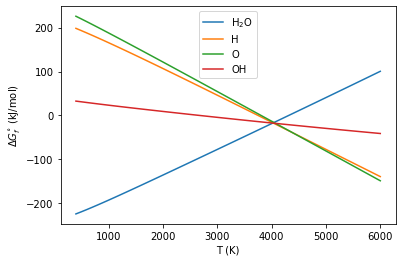

In [8]:
plt.plot(H2O["T"], H2O["dG"], label=r"H$_2$O")
plt.plot(H["T"], H["dG"], label="H")
plt.plot(O["T"], O["dG"], label="O")
plt.plot(OH["T"], OH["dG"], label="OH")
plt.xlabel("T (K)")
plt.ylabel(r"$\Delta G_f^{\circ}$ (kJ/mol)")
plt.legend()
plt.show()

#### Step 4. Initialize Gibbs-free-energy minimization
We are now ready to set up the Gibbs-free-energy-minimization routine. First, we
set the initial numbers of moles of H<sub>2</sub>O(g), H<sub>2</sub>(g),
O<sub>2</sub>(g), H(g), O(g), and OH(g).

In [9]:
N_H2O = 0.99  # not exactly 0 or 1 to avoid numerical issues
N_H2 = 0.01
N_O2 = 0.01
N_H = 0.01
N_O = 0.01
N_OH = 0.01
N = [N_H2O, N_H2, N_O2, N_H, N_O, N_OH]

#### Step 5. Calculate equilibrium composition (X) vs. T in a stepwise fashion
###### Define atomic-balance constraint

In [10]:
constraint = ({"type": "eq",
               # 2 * N_H2O + 2 * N_H2 + N_H + N_OH - 2 mol H in H2O at start = 0
               "fun": lambda x: 2 * x[0] + 2 * x[1] + x[3] + x[5] - 2},
              {"type": "eq",
               # N_H2O + 2 * N_O2 + N_O + N_OH - 1 mol O in H2O at start = 0
               "fun": lambda x: x[0] + 2 * x[2] + x[4] + x[5] - 1})
bnds = ((0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2))

###### Define objective function

In [11]:
def gibbs_free_energy(N_guess, dGfs, Press=1):
    """
Calculate nG/RT for guessed composition and standard formation free energies
    """
    N_guess = np.array(N_guess)
    N_total = N_guess.sum()
    y = N_guess / N_total  # mole fractions
    ln_y = np.log(y)
    dGfs = np.array(dGfs)
    partial_molar_gibbs_free_energy = N_guess * (dGfs + ln_y + np.log(Press))
    return partial_molar_gibbs_free_energy.sum()

In [12]:
X = []
R = 0.008314462618  # kJ/(mol K)
P = 1  # bar
for i in range(H2O.shape[0]):
    T = H2O["T"].iloc[i]
    RT = R * T
    dGf_H2O = H2O["dG"].iloc[i] / RT
    dGf_H2 = 0  # standard state
    dGf_O2 = 0
    dGf_H = H["dG"].iloc[i] / RT
    dGf_O = O["dG"].iloc[i] / RT
    dGf_OH = OH["dG"].iloc[i] / RT
    dGf = [dGf_H2O, dGf_H2, dGf_O2, dGf_H, dGf_O, dGf_OH]

    # Minimize G
    result = minimize(fun=gibbs_free_energy, x0=N, args=(dGf, P), bounds=bnds,
                      method="SLSQP", tol=1e-6, constraints=constraint)
    N = result.x  # equilibrium composition at T and P
    X.append(N)
X = np.array(X)

/var/folders/n9/q030dl3x6qgfqffys4wc7d4c0000gn/T/ipykernel_35448/295534649.py:8: RuntimeWarning: divide by zero encountered in log
  ln_y = np.log(y)
/var/folders/n9/q030dl3x6qgfqffys4wc7d4c0000gn/T/ipykernel_35448/295534649.py:10: RuntimeWarning: invalid value encountered in multiply
  partial_molar_gibbs_free_energy = N_guess * (dGfs + ln_y + np.log(Press))


#### Step 6. Plot equilibrium mole fractions

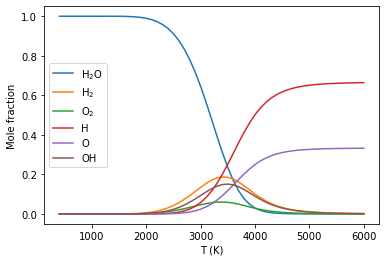

In [13]:
Y = normalize(X, norm="l1")  # convert moles to mole fractions
plt.plot(H2O["T"], Y[:, 0], label=r"H$_2$O")
plt.plot(H2O["T"], Y[:, 1], label=r"H$_2$")
plt.plot(H2O["T"], Y[:, 2], label=r"O$_2$")
plt.plot(H2O["T"], Y[:, 3], label=r"H")
plt.plot(H2O["T"], Y[:, 4], label=r"O")
plt.plot(H2O["T"], Y[:, 5], label=r"OH")
plt.xlabel("T (K)")
plt.ylabel("Mole fraction")
plt.legend()
plt.show()